In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data_dir = '/path/data'

## binary method

In [ ]:
def plot_box_binary(df, df_melt, ct):
    # Create top and bottom subplots with no vertical spacing
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True, gridspec_kw={'hspace': 0, 'height_ratios': [1.05, 1.05]})

    # Calculate means (based on the original df)
    mean_mcc = df.groupby('dis')['mcc'].mean().values
    mean_f1 = df.groupby('dis')['f1'].mean().values
    preds_mean_mcc = df.groupby('dis')['preds_mcc'].mean().values
    preds_mean_f1 = df.groupby('dis')['preds_f1'].mean().values

    x_positions = range(len(mean_mcc))
    dis_vals = sorted(df['dis'].unique())
    x_labels = [f'{int(d/1e5)}e5' for d in dis_vals]

    # ==================== Core modification: Split by Metric Type ====================
    # Separate data into F1 and MCC for the top and bottom panels respectively
    df_melt_f1 = df_melt[df_melt['metrics'].isin(['Perturbation F1', 'Correlation F1'])]
    df_melt_mcc = df_melt[df_melt['metrics'].isin(['Perturbation MCC', 'Correlation MCC'])]

    # ==================== Top Panel (ax1): F1 Metrics ====================
    if not df_melt_f1.empty:
        sns.boxplot(data=df_melt_f1, x='dis', y='binary', hue='metrics',
                    palette=["#7091DD", "#FF4F4F"], width=0.6, ax=ax1,
                    hue_order=['Perturbation F1', 'Correlation F1'], gap=0.15) 

    # Scatter and lines for F1
    ax1.scatter([x - 0.15 for x in x_positions], mean_f1, 
                color='darkblue', s=100, marker='s', label='Mean F1 (Perturb)', zorder=5)
    ax1.scatter([x + 0.15 for x in x_positions], preds_mean_f1, 
                color='#990000', s=100, marker='s', label='Mean F1 (Corr)', zorder=5)

    ax1.set_ylim(0, 1.05) 
    ax1.set_ylabel('F1', fontsize=26)
    ax1.set_title(f'{ct}', fontsize=28, pad=20)
    ax1.set_xlabel('') 

    # Independent Legend for ax1 (F1)
    handles1, labels1 = ax1.get_legend_handles_labels()
    h1, l1 = [], []
    for h, l in zip(handles1, labels1):
        if l not in l1 and l != 'metrics':
            h1.append(h)
            l1.append(l)
    ax1.legend(h1, l1, loc='upper right', fontsize=18, ncol=2, framealpha=0.9)
    # ax1.get_legend().remove()

    # ==================== Bottom Panel (ax2): MCC Metrics ====================
    if not df_melt_mcc.empty:
        sns.boxplot(data=df_melt_mcc, x='dis', y='binary', hue='metrics',
                    palette=['#66C2A5', '#FC8D62'], width=0.6, ax=ax2,
                    hue_order=['Perturbation MCC', 'Correlation MCC'], gap=0.15)

    # Scatter and lines for MCC
    ax2.scatter([x - 0.15 for x in x_positions], mean_mcc, 
                color='darkgreen', s=100, marker='s', label='Mean MCC (Perturb)', zorder=5)
    ax2.scatter([x + 0.15 for x in x_positions], preds_mean_mcc, 
                color='#B33900', s=100, marker='s', label='Mean MCC (Corr)', zorder=5)

    ax2.set_ylim(0, 1.1)
    ax2.set_ylabel('MCC', fontsize=26)
    ax2.set_xlabel('Distance from gene (bp)', fontsize=26)

    # Independent Legend for ax2 (MCC)
    handles2, labels2 = ax2.get_legend_handles_labels()
    h2, l2 = [], []
    for h, l in zip(handles2, labels2):
        if l not in l2 and l != 'metrics':
            h2.append(h)
            l2.append(l)
    ax2.legend(h2, l2, loc='upper right', fontsize=18, ncol=2, framealpha=0.9)
    # ax2.get_legend().remove()

    # ==================== Axes and Global Styling ====================
    for ax in [ax1, ax2]:
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
        ax.tick_params(axis='both', which='major', labelsize=24)
        
    ax2.set_xticks(x_positions)
    ax2.set_xticklabels(x_labels)

    plt.tight_layout()
    plt.savefig(data_dir + f'/perturbation_retina/figs/gene_peak_regulation_top_gene_{ct}_mcc_f1.pdf', format='pdf', dpi=300)
    plt.show()

## auprc method

In [ ]:
def plot_box(df, df_melt, ct):
    plt.figure(figsize=(14, 6))

    name_mapping = {
        'epiGen': 'epiGen Perturbation',
        'Prediction': 'Correlation',
        'Random': 'Random'
    }
    df_melt['Method'] = df_melt['Method'].map(name_mapping)

    sns.boxplot(data=df_melt, x='dis', y='AUPR', hue='Method',
                palette=['#66C2A5', "#7091DD", '#FC8D62'], width=0.8, gap=0.15)

    mean_aupr_epiGen = df.groupby('dis')['epiGen_aupr'].mean()
    mean_aupr_preds = df.groupby('dis')['preds_aupr'].mean()
    mean_aupr_random = df.groupby('dis')['random_aupr'].mean()

    x_positions = range(len(mean_aupr_epiGen))
    plt.scatter([x - 0.27 for x in x_positions], mean_aupr_epiGen, 
                color='darkgreen', s=100, marker='s', label='Mean epiGen Perturbation', zorder=5)
    plt.scatter([x for x in x_positions], mean_aupr_preds, 
                color='darkblue', s=100, marker='s', label='Mean Correlation', zorder=5)
    plt.scatter([x + 0.27 for x in x_positions], mean_aupr_random, 
                color='darkred', s=100, marker='s', label='Mean Random', zorder=5)

    ax = plt.gca()
    dis_vals = sorted(df['dis'].unique())
    ax.set_xticklabels([f'{int(d/1e5)}e5' for d in dis_vals])
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    plt.xlabel('Distance from gene (bp)', fontsize=22)
    plt.ylabel('AUPRC', fontsize=22)
    plt.title(f'{ct}', fontsize=24, pad=20)
    plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=22)
    plt.ylim(0, 1.0)
    plt.xticks(fontsize=22)
    plt.yticks(fontsize=22)

    plt.tight_layout()
    plt.savefig(data_dir + f'/perturbation_retina/figs/gene_peak_regulation_top_gene_{ct}.pdf', format='pdf', dpi=300)
    plt.show()

## auprc

In [4]:
ct = 'RGCs'

/tmp/ipykernel_1395899/663375117.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{int(d/1e5)}e5' for d in dis_vals])


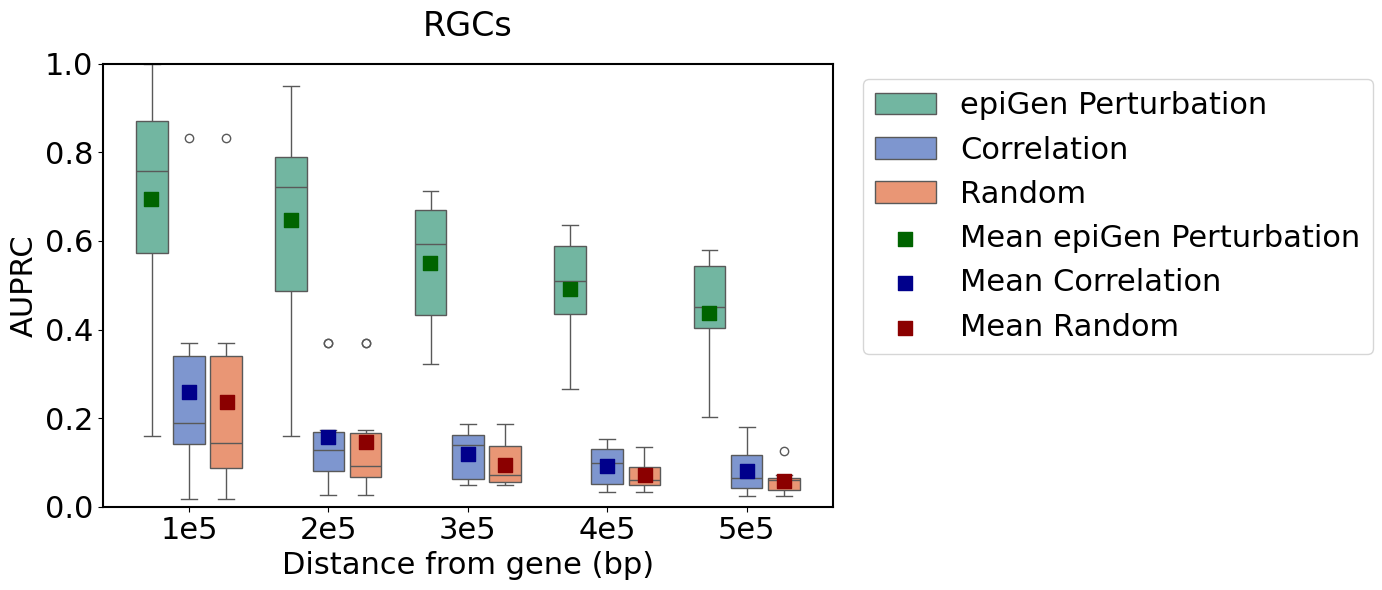

In [5]:
df = pd.read_csv(data_dir + f"/perturbation_retina/gene_peak_nearby/nearby_aupr_{ct}_permutation.csv", index_col=0).iloc[:, :25]
df.columns = ['dis', 'gene_name', 'epiGen_aupr', 'auroc', 'mcc', 'f1', 
              'top10_prec', 'top50_prec', 'top100_prec', 'top10_rec', 'top50_rec', 'top100_rec', 
              'preds_auroc', 'preds_aupr', 'preds_mcc', 'preds_f1', 
              'preds_top10_prec', 'preds_top50_prec', 'preds_top100_prec', 'preds_top10_rec', 'preds_top50_rec', 'preds_top100_rec', 
              'n_total_peaks', 'n_positive_peaks', 'random_aupr']
original_gene_order = df['gene_name'].unique().tolist()
df['gene_name'] = pd.Categorical(df['gene_name'], categories=original_gene_order, ordered=True)
df = df.sort_values(['gene_name', 'dis'], ascending=[True, True])
df_melt = pd.melt(df, 
                  id_vars=['dis', 'gene_name'],
                  value_vars=['epiGen_aupr', 'preds_aupr', 'random_aupr'],
                  var_name='Method',
                  value_name='AUPR')

df_melt['Method'] = df_melt['Method'].map({
    'epiGen_aupr': 'epiGen',
    'preds_aupr': 'Prediction',
    'random_aupr': 'Random'
})

plot_box(df, df_melt, ct)

## binary

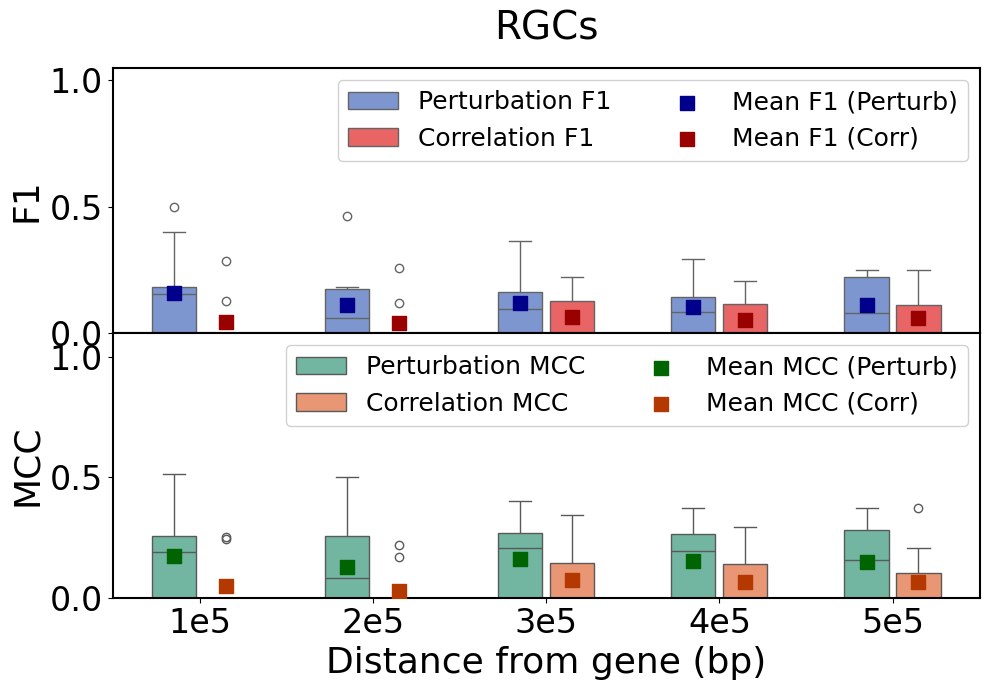

In [6]:
df = pd.read_csv(data_dir + f"/perturbation_retina/gene_peak_nearby/nearby_aupr_{ct}_permutation.csv", index_col=0).iloc[:, :25]
df.columns = ['dis', 'gene_name', 'epiGen_aupr', 'auroc', 'mcc', 'f1', 
              'top10_prec', 'top50_prec', 'top100_prec', 'top10_rec', 'top50_rec', 'top100_rec', 
              'preds_auroc', 'preds_aupr', 'preds_mcc', 'preds_f1', 
              'preds_top10_prec', 'preds_top50_prec', 'preds_top100_prec', 'preds_top10_rec', 'preds_top50_rec', 'preds_top100_rec', 
              'n_total_peaks', 'n_positive_peaks', 'random_aupr']
original_gene_order = df['gene_name'].unique().tolist()
df['gene_name'] = pd.Categorical(df['gene_name'], categories=original_gene_order, ordered=True)
df = df.sort_values(['gene_name', 'dis'], ascending=[True, True])
df_melt = pd.melt(df, 
                  id_vars=['dis', 'gene_name'],
                  value_vars=['mcc', 'f1', 'preds_mcc', 'preds_f1'],
                  var_name='metrics',
                  value_name='binary')
df_melt['metrics'] = df_melt['metrics'].map({
    'mcc': 'Perturbation MCC',
    'f1': 'Perturbation F1',
    'preds_mcc': 'Correlation MCC',
    'preds_f1': 'Correlation F1'
})

plot_box_binary(df, df_melt, ct)